# Simple Linear Regression

In this chapter, we will introduct our first model , **simple linear regression** . Simple Linear Regression models the relationship between one response variable and one feature variable of an explanatory variable. We will discuss how to fit our modl and we will work throught a topy problem. While simple linear regression is rarely applicable to real-world problems, understanding it is essential to understanding many other models. In subsequent chapters, we will learn about generalizations of simple linear regression and apply them to real-world datasets.

## 1. Simple Linear Regression

In the previous chapter, we learned that training data is used to estimate the parameters of a model in supervised learning problems. Observations of explanatory variables and their corresponding response variables comprise training data. The model can be used to predict the value of the response variable for values of the explanatory variable that have not been previously observed. Recall that the goal in **regression problems is to predict the value of a continuous response variable**. In this chapter, we will examine simple linear regression, which can be used to model a linear relationship between one response variable and one feature representing an explanatory variable.

Suppose you wish to know the price of a pizza. You might simply look at a menu. This, however, is a machine learning book, so instead we will use simple linear regression to predict the price of a pizza based on an attribute of the pizza that we can observe, or an explanatory variable. Let's model the relationship between the size of a pizza and its price. First, we will write a program with scikit-learn that can predict the price of a pizza given its size. Then we will discuss how simple linear regression works and how it can be generalized to work with other types of problems.


Lets assume that you have recorded the diameters and price of pizzas that you have previously eaten in your pizza journal that looks something like this:

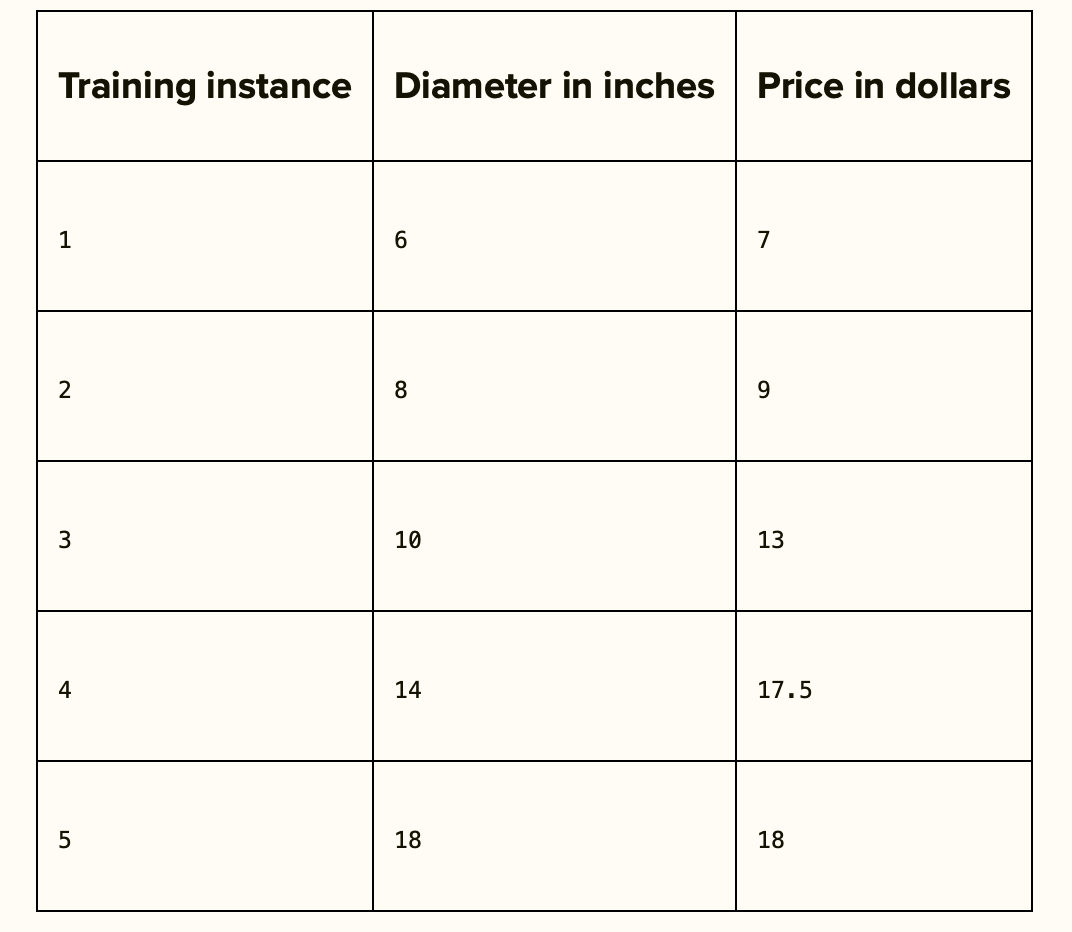

We can visualize out traning data by plottint it on a grap using `matplotlib`:



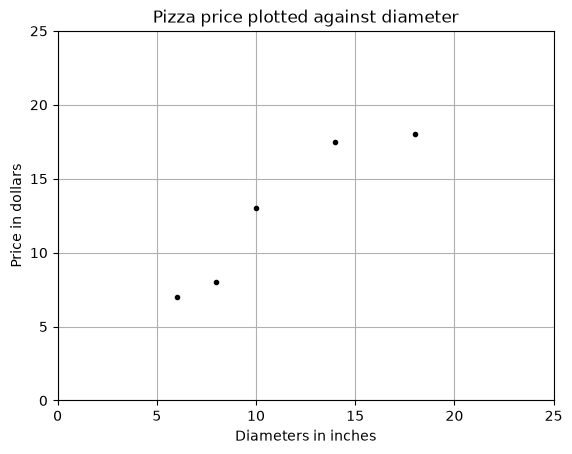

In [2]:
import numpy as np
import matplotlib.pyplot as plt


# X represents the features of our training data, the diameters of the pizzas. 
# A scikit-learn convention is to name the matrix of feature vectors X.  
# Uppercase letters indicate matrices, and lowercase letters indicate vectors.
X = np.array([[6], [8], [10], [14], [18]]).reshape(-1,1)
y = [7,8,13,17.5,18] #Vector represnting prices

plt.figure()
plt.title('Pizza price plotted against diameter')
plt.xlabel('Diameters in inches')
plt.ylabel('Price in dollars')
plt.plot(X, y,'k.')
plt.axis([0, 25, 0, 25]) 
plt.grid(True) 
plt.show()

**Note**:The comments in the script state that X represents a matrix of pizza diameters, and y represents a vector of pizza prices. The reasons for this decision will become clear in the next chapter. 

From the above plot we can see that there is a positive relationship (correlation ) betwen the diameter and price, which should be corraborated by our own pizza-eating experience. As the diameter of pizza increases, its price generally increases.The following price predictor program models this relationship using simple linear regression.

In [3]:
from sklearn.linear_model import LinearRegression

#Intiallize our model
model = LinearRegression()

#Fitting or Training our model to Labels and Features
model.fit(X, y)

#Predict the price using model predctions
test_pizza = np.array([[12]])
predicted_price = model.predict(test_pizza)[0]
print('A 12" pizza should cost: $%.2f' % predicted_price) 

A 12" pizza should cost: $13.51


Simple linear regression assumes that a linear relationship exists between the response variable and the explanatory variable; it models this relationship with a linear surface called a **hyperplane**.  A hyperplane is a subspace that has one dimension less that the ambient space that contains it. In  Simple linear regresison, there is one dimension for the resoponse variable and another dimension for the explanatory variable , for a total of two dimensions. The regression hyperplane thus has one dimentions; a hyperplane with one dimension is a line.


The **LinearRegression** class is an **estimator**.  Estimators predict a value based on obeserved data. In  scikit-learn , all estimators implement the `fit` method and `predict` . The former method is used to learn the parameters of a model and the later method is used to predict the value of a response variable for an explanatory variable using the learned parameters. Its easy to experiment with different models using scikit learn because all estimators implement the `fit` and `predict` methods; trying new models can be as simple as changing one line of code.The `fit` method of `LinearRegression` learns the parameters of the following models for linear regression:


$$y = \alpha + \beta * x$$

In the preceding formula, y is the predicted value of the response variable; in this example, it is the predicted price of the pizza. x is the explanatory variable. The intercept term `α` and the coefficient `β` are parameters of the model that are learned by the learning algorithm. The hyperplane plotted in the following figure models the relationship between the size of a pizza and its price. Using this model, we would expect the price of an 8" pizza to be about `$7.33` and the price of a 20" pizza to be `$18.75`.

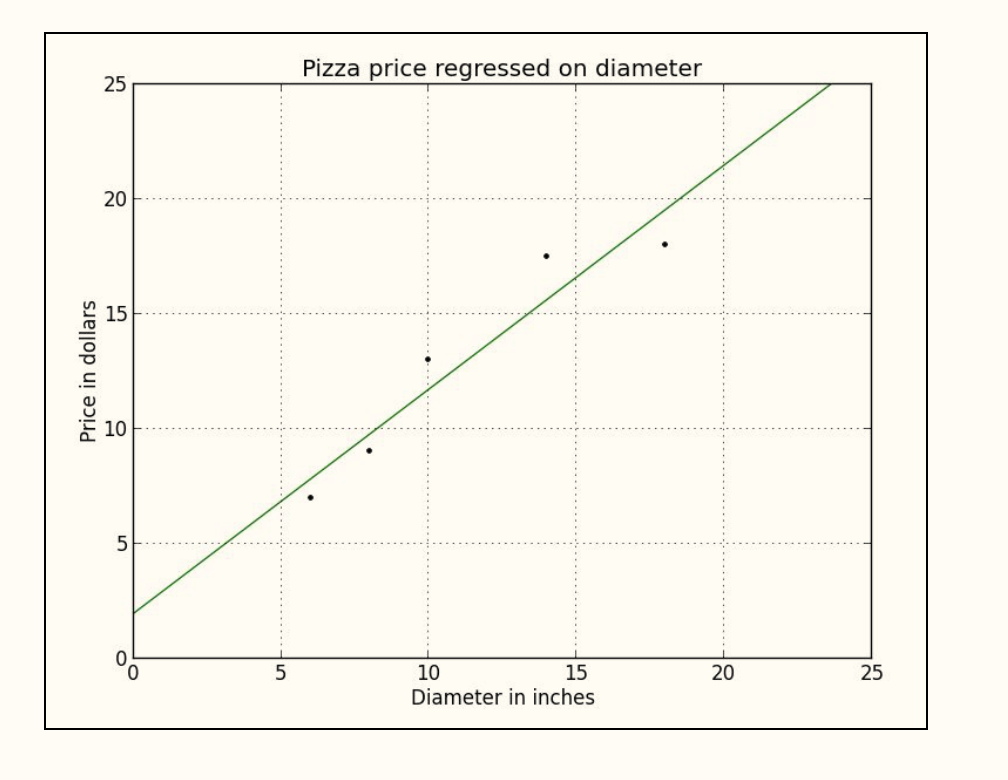

Using training data to learn the values of the parameters for simple linear regression that produce the best fitting model is called **ordinary least squares (OLS)** or **linear least squares**. In this chapter, we will discuss a method for analytically solving the values of the model's parameters. In subsequent chapters, we will learn approaches for approximating the values of parameters that are suitable for larger datasets. First, however, we must define what it means for a model to fit the training data.


## 3. Evaluating the fitness of the model with a cost function

Regression lines produced by several sets of parameter values are plotted in the following figure. How can we assess which parameters produced the best-fitting regression line?

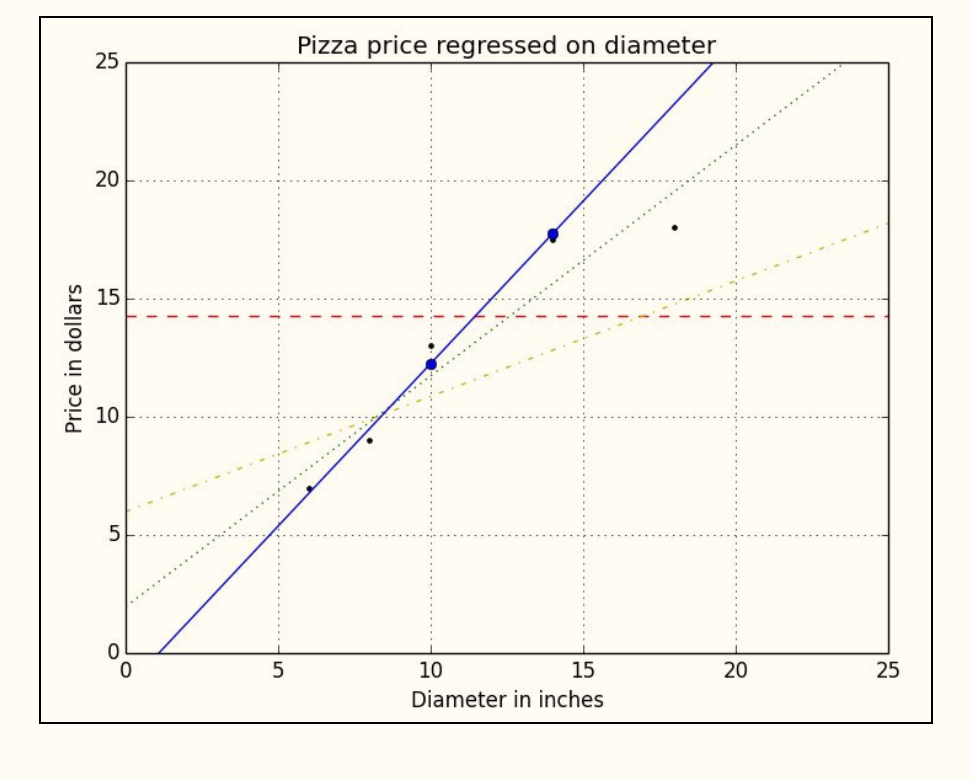

The **cost functions** , also called the **loss function**,is used to define and measure the error of a model. The differences between the prices predicted by the model and obeserved price of the pizzas in the training set are called **residuals** or **tranining errors**. Later we will evaluate the model on a sperate set of test data. The difference between predicted and observed values in the test data are called **prediction errors** or **test errors**. The residuals for our models are indicated by vertical lines between the points for the traning instances and the regression hyperplane in the following plots:

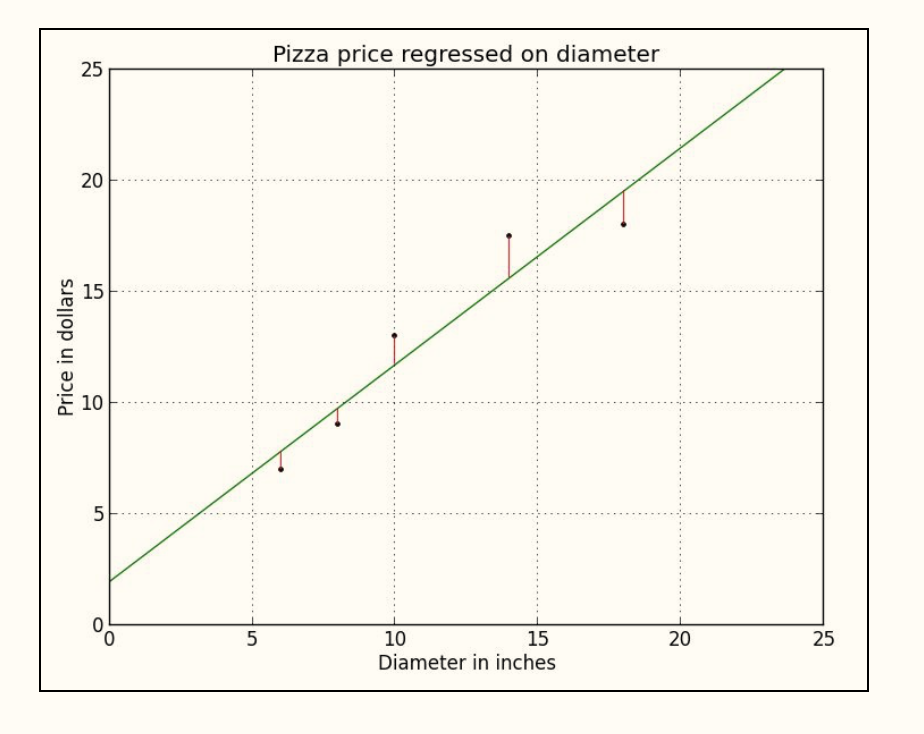

We can produce the best pizza-price predictor by minimizing the sum of the residuals. That is, our model fits if the values it predicts for the response variable are close to the observed values for all of the training examples. This measure of the model's fitness is called the **residual sum of squares** (RSS) cost function. Formally, this function assesses the fitness of a model by summing the squared residuals for all of our training examples. The RSS is calculated with the formula in the following equation, where `yi` is the observed value and `f(xi)` is the predicted value:

$$ SS_{res} = \sum_{i=1}^{n} (y_{i} - f(x_{i})^{2}$$

Let's compute the RSS for our model by adding the following two lines to the previous script:

In [4]:
print('Residual sum of squares: %.2f' % np.mean((model.predict(X)  - y) ** 2)) 

Residual sum of squares: 2.20


Now that we have a cost function, we can find the values of the model's parameters that minimize it.

## 4. Sovling OLS for Simple Linear Regression

In this section, we will work through solving OLS for Simple Linear Regression. Recall that simple linear regression is give by the equation: $y = \alpha + \beta * x$ and our four goals is to solve for the values of β and α to minimize the cost function. We will solve for β first . To do so we will calculate **variance** of x and **covariance** of x and y. Variance is an measure of how far a set of value are spread out. If all the numbers in the set are equal, the variance of the set is zero. A small variance indicates that the numbers are near the mean of the set, while a set containing numbers that are far from the mean and from each other will have a large variance. Variance can be calculated using the following equation:

$$ Var(x) = \sum_{i=1}^{n}(x_{i} - x^{|}) / n - 1$$

$x^{|}$ is the mean of x and $x_{i}$ is the value of x for the $i^{th}$ traning instance and n is the number of instances. Lets calculate *variance* for the pizza diameters in our traning set:


In [5]:
import numpy as np


X = np.array([[6], [8], [10], [14], [18]]).reshape(-1, 1)
X_bar = X.mean()
print(X_bar)

# Note that we subtract one from the number of training instances when  calculating the sample variance. 
# # This technique is called Bessel's correction. 
# It corrects the bias in the estimation of the population variance for the sample
variance = ((X- X_bar)**2).sum() / (X.shape[0] - 1)
print(variance)

11.2
23.2


NumPy also provides the method *var* for calculating variance. The keyword parameter *ddof* can be used to set Bessel's correction to calculate the sample variance:

In [6]:
print(np.var(X, ddof=1))

23.2


Covariance is a measure of how much two variables change together. If the variables increase together, their covariance is positive. If one variable tends to increase while the other decreases, their covariance is negative. If there is no linear relationship between the two variables their covariance will be equal to zero; they are linearly uncorrelated but not necessarily independent. Covariance can be calculated using the following formula:

$$ cov(x,y) = \sum_{i=1}^{n} (x_{i} - x^{|}) * (y_{i} - y^{|}) / n-1 $$


As with variance, $x^{i}$ is the diameter of the $i^{th}$ training instance,  $x^{|}$ is the mean of the diameters,  $y^{|}$ is the mean of the prices,  $y^{i}$ is the price of the $i^{th}$ training instance, and n is the number of training instances. Let's calculate covariance of the diameters and prices of the pizzas in the training set:


In [7]:
#Here we switch to a NumPy ndarray, 
#which provides a method to calulcate the sample mean.
y = np.array([7,9,13,17.5,18])

y_bar = y.mean()
# We transpose X because both operands must be row vectors
covariance = np.multiply((X - X_bar).transpose(), y - y_bar).sum() /   (X.shape[0] - 1)
print(covariance)
print(np.cov(X.transpose(), y)[0][1])

22.65
22.65


Now that we have calculated the variance of our explanatory variable and the covariance of the response and explanatory variables, we can solve for β using the following:

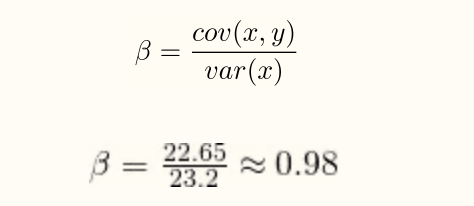

Having solved for β, we can solve for α using this formula:

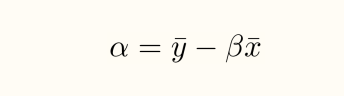

Here, $y^{|}$ is the mean of y and $x^{|}$  is the mean of $x*{x^{|} *y^{|} }$ are the coordinates of the centroid, a point that the model must pass through.

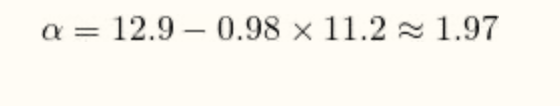


Now that we have solved for the values of the model's parameters that minimize the cost function, we can plug in the diameters of the pizzas and predict their prices. For instance, an `11"` pizza should be expected to cost about `$12.70`, and an `18"` pizza should be expected to cost `$19.54`. Congratulations! You used simple linear regression to predict the price of a pizza.

## 5. Evaluating the model

We have used a learning algorithm to estimate a model's parameters from training data. How can we assess whether our model is a good representation of the real relationship? Let's assume that you have found another page in your pizza journal. We will use this page's entries as a test set to measure the performance of our model. We have added a fourth column; it contains the prices predicted by our model.

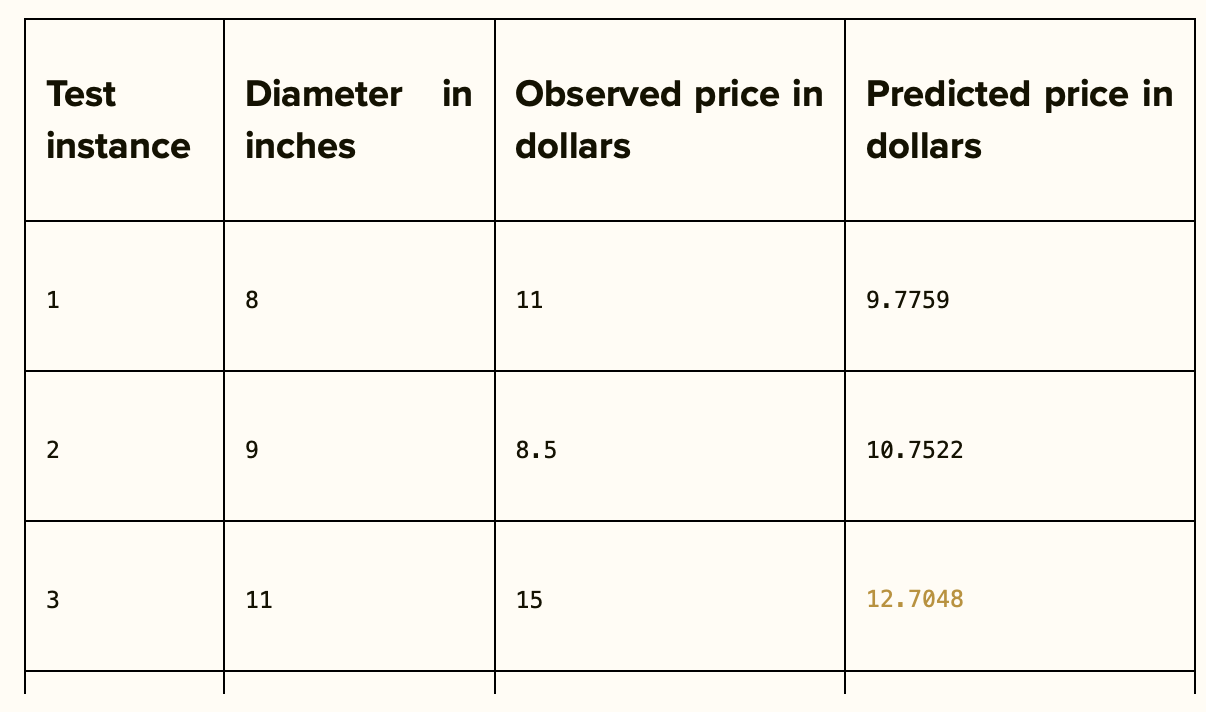
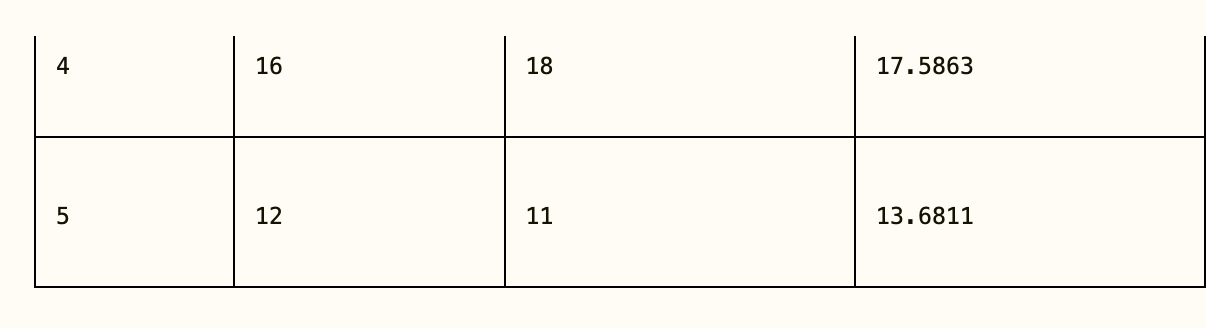

Several measures can be used to assess our model's predictive capability. We will evaluate our pizza price predictor using a measure called **R-squared**. Also known as the **coefficient of determination**, R-squared measures how close the data are to a regression line. There are several methods for calculating R-squared. In the case of simple linear regression, R-squared is equal to the square of the **Pearson product-moment correlation coefficient**(PPMCC), or **Pearson's r**. Using this method, R-squared must be a positive number between zero and one. “This method is intuitive; if R-squared describes the proportion of variance in the response variable that is explained by the model, it cannot be greater than one or less than zero. Other methods, including the method used by scikit-learn, do not calculate R-squared as the square of Pearson's r. Using these methods, R-squared can be negative if the model performs extremely poorly. It is important to note the limitations of performance metrics. R-squared in particular is sensitive to outliers, and can spuriously increase when features are added to the model.

We will follow the method used by scikit-learn to calculate R-squared for our pizza price predictor. First we must measure the **total sum of squares**. $y_{i}$ is the observed value of the response variable for the $i^{th}$ test instance, $y_{|}$ and  is the mean of the observed values of the response variable.

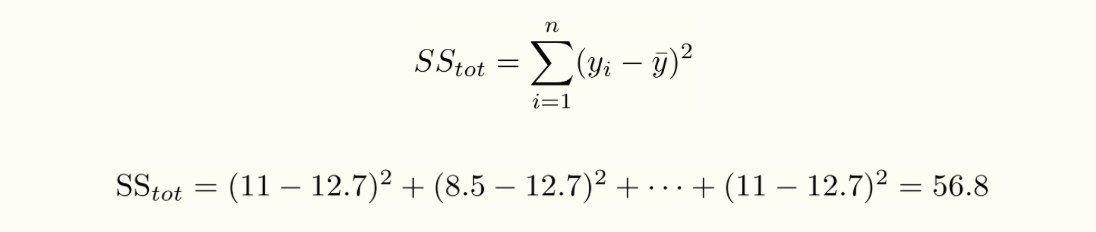

Next we must find the RSS. Recall that this is also our cost function.

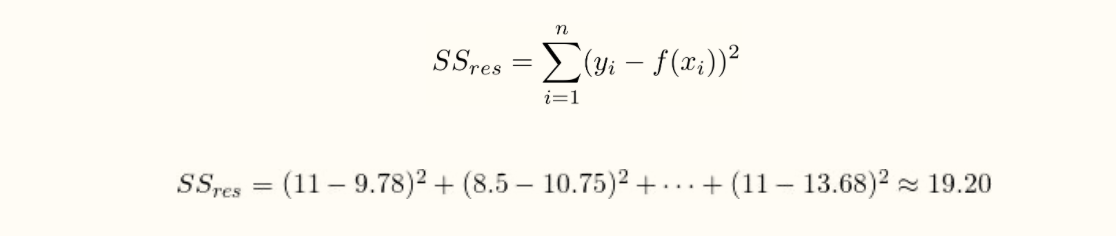


Finally, we can find R-squared using the following:

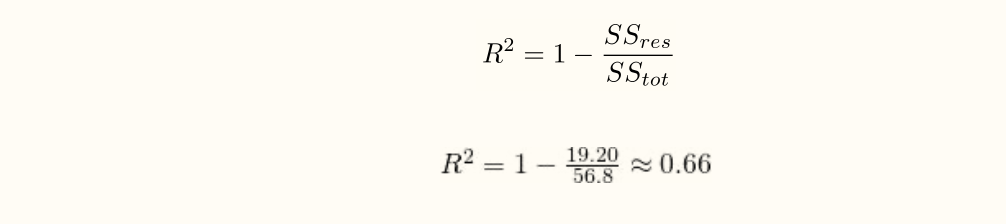

The R-squared score of 0.662 indicates that a large proportion of the variance in the test instances' prices is explained by the model. Now let's confirm our calculation using scikit-learn. The score method of LinearRegression returns the model's R-squared value, as seen in the following example:

In [8]:
import numpy as np 
from sklearn.linear_model import LinearRegression  

X_train = np.array([6, 8, 10, 14, 18]).reshape(-1, 1) 
y_train = [7, 9, 13, 17.5, 18]  
X_test = np.array([8, 9, 11, 16, 12]).reshape(-1, 1) 
y_test = [11, 8.5, 15, 18, 11]   

model = LinearRegression()
model.fit(X_train, y_train) 

r_squared = model.score(X_test, y_test) 
print(r_squared )



0.6620052929422553


## Summary
In this chapter, we introduced simple linear regression, which models the relationship between a single explanatory variable and a continuous response variable. We worked through a toy problem to predict the price of a pizza from its diameter. We used the residual sum of squares cost function to assess the fitness of our model, and analytically solved the values of our model's parameter that minimized the cost function. We measured the performance of our model on a test set. Finally, we introduced scikit-learn's estimator API. In the next chapter, we will compare and contrast simple linear regression with another simple, ubiquitous model, **k-Nearest Neighbors (KNN)**